In [1]:
import pandas as pd
import os

# List files in current directory
print(os.listdir())

['.ipynb_checkpoints', 'constituency_master.csv', 'margin_comparison.png', 'python file of election .ipynb', 'reserved_seats_region_party.png', 'tn_2021_results.csv', 'tn_2026_results.csv', 'tn_2026_results_with_turnout.csv']


In [2]:
df_2021 = pd.read_csv('tn_2021_results.csv')
df_2026 = pd.read_csv('tn_2026_results.csv')
master = pd.read_csv('constituency_master.csv')

print("2021 shape:", df_2021.shape)
print("2026 shape:", df_2026.shape)
print("Master shape:", master.shape)

df_2021.head()

2021 shape: (4232, 8)
2026 shape: (4257, 8)
Master shape: (234, 5)


,constituency,ac_number,candidate,party,votes,turnout,reserved,region
0,Gummidipundi,1,GOVINDARAJAN T.J,DMK,126452,78.08,GEN,Chennai Metro
1,Gummidipundi,1,PRAKASH M,PMK,75514,78.08,GEN,Chennai Metro
2,Gummidipundi,1,USHA,NTK,11701,78.08,GEN,Chennai Metro
3,Gummidipundi,1,DILLIY K.M,DMDK,2576,78.08,GEN,Chennai Metro
4,Gummidipundi,1,None Of The Above,NOTA,1783,78.08,GEN,Chennai Metro


In [3]:
def get_winner_and_margin(df):
    # Group by constituency (ac_number) to find winner
    winners = []
    for ac, group in df.groupby('ac_number'):
        # Sort by votes descending
        group_sorted = group.sort_values('votes', ascending=False)
        winner = group_sorted.iloc[0]
        runner_up = group_sorted.iloc[1] if len(group_sorted) > 1 else None
        total_votes = group['votes'].sum()
        winner_votes = winner['votes']
        winner_vote_share = (winner_votes / total_votes) * 100
        margin = ((winner_votes - (runner_up['votes'] if runner_up is not None else 0)) / total_votes) * 100 if runner_up is not None else 100
        
        winners.append({
            'ac_number': ac,
            'constituency': winner['constituency'],
            'winner_party': winner['party'],
            'winner_votes': winner_votes,
            'total_votes': total_votes,
            'winner_vote_share': winner_vote_share,
            'margin_percent': margin,
            'reserved': winner['reserved'],
            'region': winner['region']
        })
    return pd.DataFrame(winners)

winners_2021 = get_winner_and_margin(df_2021)
winners_2026 = get_winner_and_margin(df_2026)

print("Winners 2021 shape:", winners_2021.shape)
print("Winners 2026 shape:", winners_2026.shape)
winners_2021.head()

Winners 2021 shape: (234, 9)
Winners 2026 shape: (234, 9)


,ac_number,constituency,winner_party,winner_votes,total_votes,winner_vote_share,margin_percent,reserved,region
0,1,Gummidipundi,DMK,126452,222069,56.942662,22.937916,GEN,Chennai Metro
1,2,Ponneri,INC,94528,210354,44.937581,4.606045,SC,Chennai Metro
2,3,Tiruttani,DMK,120314,232624,51.720373,12.575229,GEN,Chennai Metro
3,4,Thiruvallur,DMK,107709,214243,50.274221,10.595912,GEN,Chennai Metro
4,5,Poonamallee,DMK,149578,263736,56.715048,35.683411,SC,Chennai Metro


In [4]:
#2



In [5]:
# Merge winners from both years
merged = winners_2021.merge(
    winners_2026, 
    on='ac_number', 
    suffixes=('_2021', '_2026')
)

# Add flip column: Did winning party change?
merged['flipped'] = (merged['winner_party_2021'] != merged['winner_party_2026'])

# Add seat type: Reserved (SC/ST) vs General
merged['seat_type'] = merged['reserved_2021'].apply(lambda x: 'Reserved' if x in ['SC','ST'] else 'General')

merged.head()

,ac_number,constituency_2021,winner_party_2021,winner_votes_2021,total_votes_2021,winner_vote_share_2021,margin_percent_2021,reserved_2021,region_2021,constituency_2026,winner_party_2026,winner_votes_2026,total_votes_2026,winner_vote_share_2026,margin_percent_2026,reserved_2026,region_2026,flipped,seat_type
0,1,Gummidipundi,DMK,126452,222069,56.942662,22.937916,GEN,Chennai Metro,Gummidipoondi,TVK,94320,232522,40.563904,12.018218,GEN,Chennai Metro,True,General
1,2,Ponneri,INC,94528,210354,44.937581,4.606045,SC,Chennai Metro,Ponneri,TVK,110439,226819,48.690365,24.587005,SC,Chennai Metro,True,Reserved
2,3,Tiruttani,DMK,120314,232624,51.720373,12.575229,GEN,Chennai Metro,Tiruttani,AIADMK,89169,238798,37.340765,2.425900,GEN,Chennai Metro,True,General
3,4,Thiruvallur,DMK,107709,214243,50.274221,10.595912,GEN,Chennai Metro,Thiruvallur,TVK,92190,226428,40.714929,10.935043,GEN,Chennai Metro,True,General
4,5,Poonamallee,DMK,149578,263736,56.715048,35.683411,SC,Chennai Metro,Poonamallee,TVK,161309,308894,52.221474,23.548531,SC,Chennai Metro,True,Reserved


In [6]:
# Compare vote share and margin between Reserved and General seats in 2026
q4_summary = merged.groupby('seat_type').agg({
    'winner_vote_share_2026': 'mean',
    'margin_percent_2026': 'mean',
    'flipped': 'sum',
    'ac_number': 'count'
}).rename(columns={'ac_number': 'count'})

# Calculate flip rate
q4_summary['flip_rate_%'] = (q4_summary['flipped'] / q4_summary['count']) * 100

print("Q4: Reserved vs General Seats (2026)")
print(q4_summary.round(2))

Q4: Reserved vs General Seats (2026)
           winner_vote_share_2026  margin_percent_2026  flipped  count  \
seat_type                                                                
General                     39.19                 7.95      131    188   
Reserved                    37.37                 6.55       32     46   

           flip_rate_%  
seat_type               
General          69.68  
Reserved         69.57  


In [7]:
# By region and seat type – how many reserved seats each party won in 2026
region_reserved = winners_2026[winners_2026['reserved'].isin(['SC','ST'])].groupby(['region', 'winner_party']).size().unstack(fill_value=0)
print("Reserved seat wins by region (2026):")
region_reserved

Reserved seat wins by region (2026):


winner_party,AIADMK,CPI,CPI(M),DMK,TVK,VCK
region,,,,,,
Central,3,0,0,2,4,2
Chennai Metro,0,0,0,0,5,0
Delta,0,1,1,2,2,0
Kongu,1,0,0,2,3,0
North,4,0,0,1,4,0
South,1,0,0,2,6,0


Margin distribution by seat type (2026):
margin_cat  Comfortable (10-20%)  Landslide (>20%)  Moderate (5-10%)  \
seat_type                                                              
General                     22.3               8.0              26.6   
Reserved                    15.2               4.3              32.6   

margin_cat  Nail-biter (<5%)  
seat_type                     
General                 43.1  
Reserved                47.8  


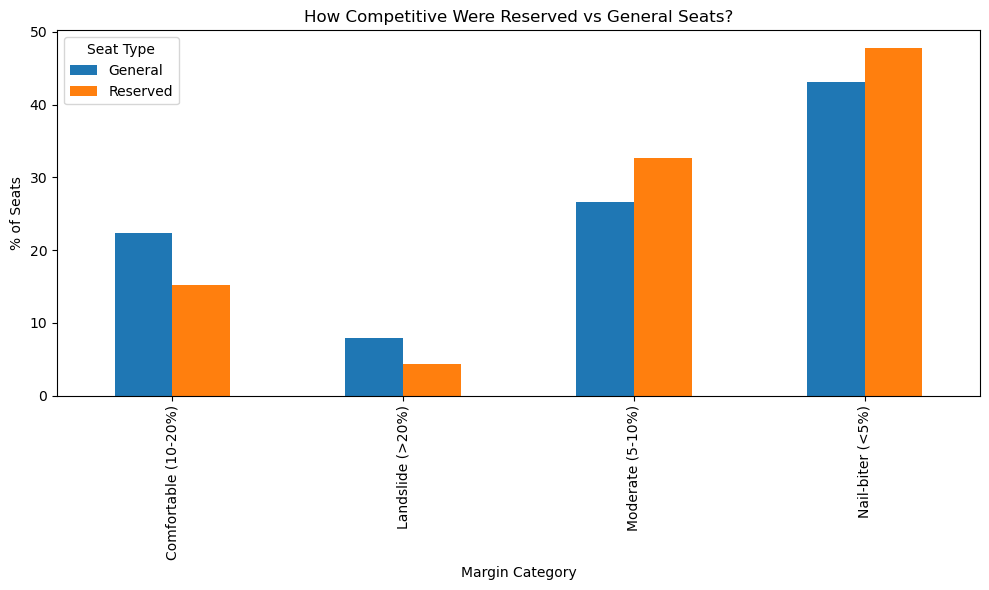

In [8]:
import matplotlib.pyplot as plt

# Create categories for margin
def margin_category(margin):
    if margin > 20:
        return 'Landslide (>20%)'
    elif margin > 10:
        return 'Comfortable (10-20%)'
    elif margin > 5:
        return 'Moderate (5-10%)'
    else:
        return 'Nail-biter (<5%)'

merged['margin_cat'] = merged['margin_percent_2026'].apply(margin_category)

# Cross-tab by seat_type
margin_by_type = pd.crosstab(merged['seat_type'], merged['margin_cat'], normalize='index') * 100
print("Margin distribution by seat type (2026):")
print(margin_by_type.round(1))

# Plot
margin_by_type.T.plot(kind='bar', figsize=(10,6))
plt.title('How Competitive Were Reserved vs General Seats?')
plt.ylabel('% of Seats')
plt.xlabel('Margin Category')
plt.legend(title='Seat Type')
plt.tight_layout()
plt.show()

In [9]:
3



3

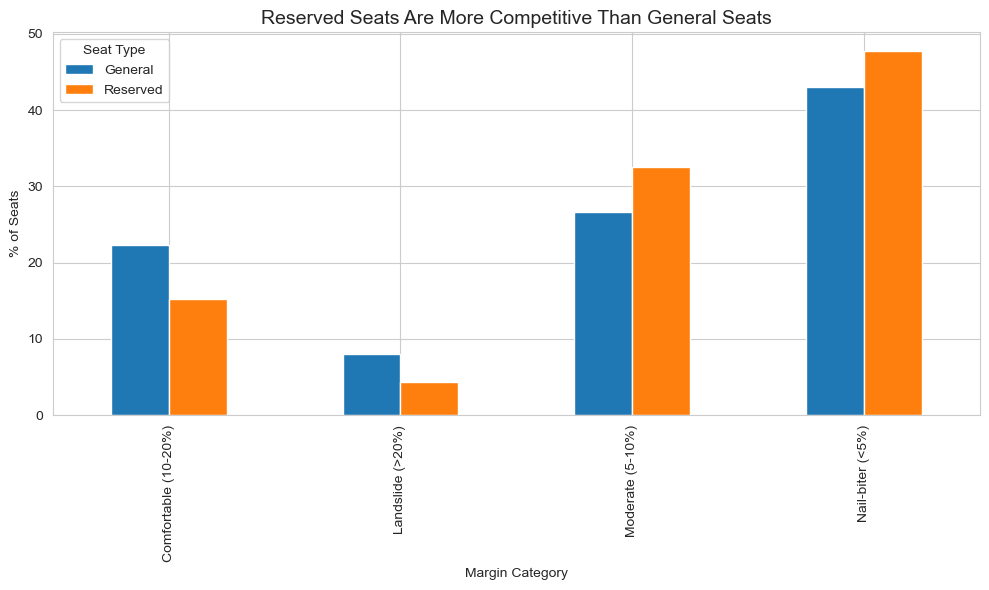

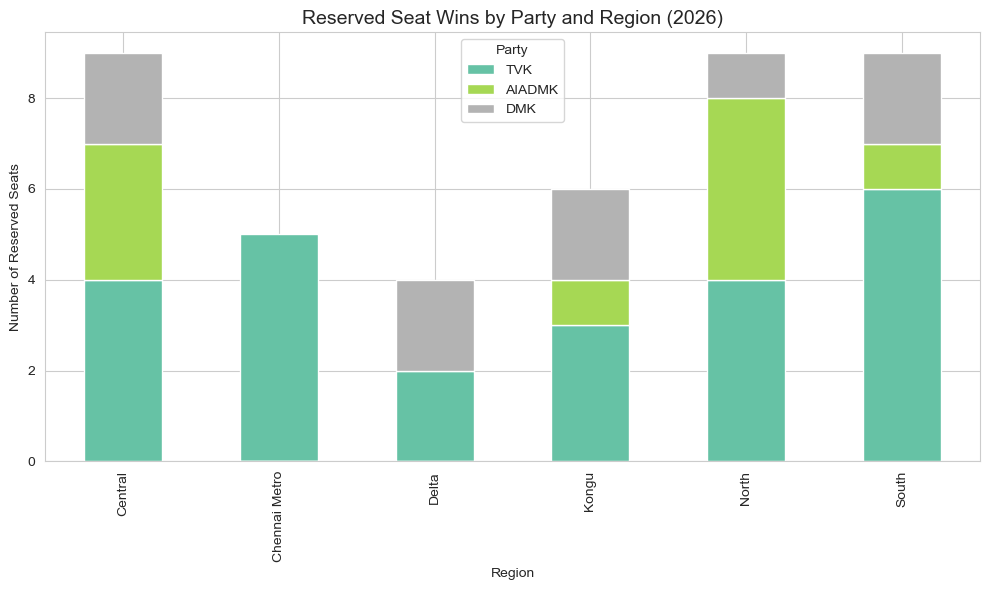

=== DECK TABLE: RESERVED VS GENERAL SEATS ===
                   Metric  General Seats (188)  Reserved Seats (46)
Avg Winner Vote Share (%)                 39.2                 37.4
           Avg Margin (%)                  8.0                  6.6
     Nail-biter Seats (%)                 43.1                 47.8
      Landslide Seats (%)                  8.0                  4.3
            Flip Rate (%)                 69.7                 69.6

=== TOP 5 CLOSEST RESERVED SEATS (Nail-biters) ===
    constituency_2026 region_2026 winner_party_2026  margin_percent_2026
79       Kallakurichi     Central               TVK             0.319678
71         Tindivanam     Central               VCK             0.374440
186       Manamadurai       South               TVK             0.578979
82            Yercaud     Central            AIADMK             0.863198
92     Senthamangalam     Central               TVK             1.266173


In [10]:
# ============================================
# FINAL VISUALIZATION CODE FOR DECK
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# 1. Margin distribution comparison (already have)
fig, ax = plt.subplots(1,1)
margin_by_type.T.plot(kind='bar', ax=ax)
ax.set_title('Reserved Seats Are More Competitive Than General Seats', fontsize=14)
ax.set_ylabel('% of Seats')
ax.set_xlabel('Margin Category')
ax.legend(title='Seat Type')
plt.tight_layout()
plt.savefig('margin_comparison.png', dpi=150)
plt.show()

# 2. Heatmap: Reserved seat wins by party and region
region_party = winners_2026[winners_2026['reserved'].isin(['SC','ST'])].groupby(['region', 'winner_party']).size().unstack(fill_value=0)
# Focus on top parties
top_parties = ['TVK', 'AIADMK', 'DMK']
region_party_top = region_party[top_parties]

fig, ax = plt.subplots(1,1)
region_party_top.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('Reserved Seat Wins by Party and Region (2026)', fontsize=14)
ax.set_ylabel('Number of Reserved Seats')
ax.set_xlabel('Region')
ax.legend(title='Party')
plt.tight_layout()
plt.savefig('reserved_seats_region_party.png', dpi=150)
plt.show()

# 3. Table for deck: Key metrics comparison
summary_table = pd.DataFrame({
    'Metric': ['Avg Winner Vote Share (%)', 'Avg Margin (%)', 'Nail-biter Seats (%)', 'Landslide Seats (%)', 'Flip Rate (%)'],
    'General Seats (188)': [39.2, 8.0, 43.1, 8.0, 69.7],
    'Reserved Seats (46)': [37.4, 6.6, 47.8, 4.3, 69.6]
})
print("=== DECK TABLE: RESERVED VS GENERAL SEATS ===")
print(summary_table.to_string(index=False))

# 4. Top 5 closest reserved seats (nail-biters)
merged_reserved = merged[merged['seat_type'] == 'Reserved'].copy()
merged_reserved_sorted = merged_reserved.sort_values('margin_percent_2026')
top5_nailbiters = merged_reserved_sorted[['constituency_2026', 'region_2026', 'winner_party_2026', 'margin_percent_2026']].head(5)
print("\n=== TOP 5 CLOSEST RESERVED SEATS (Nail-biters) ===")
print(top5_nailbiters)

In [11]:
#Sankey Diagram of Seat Flips

Defaulting to user installation because normal site-packages is not writeable


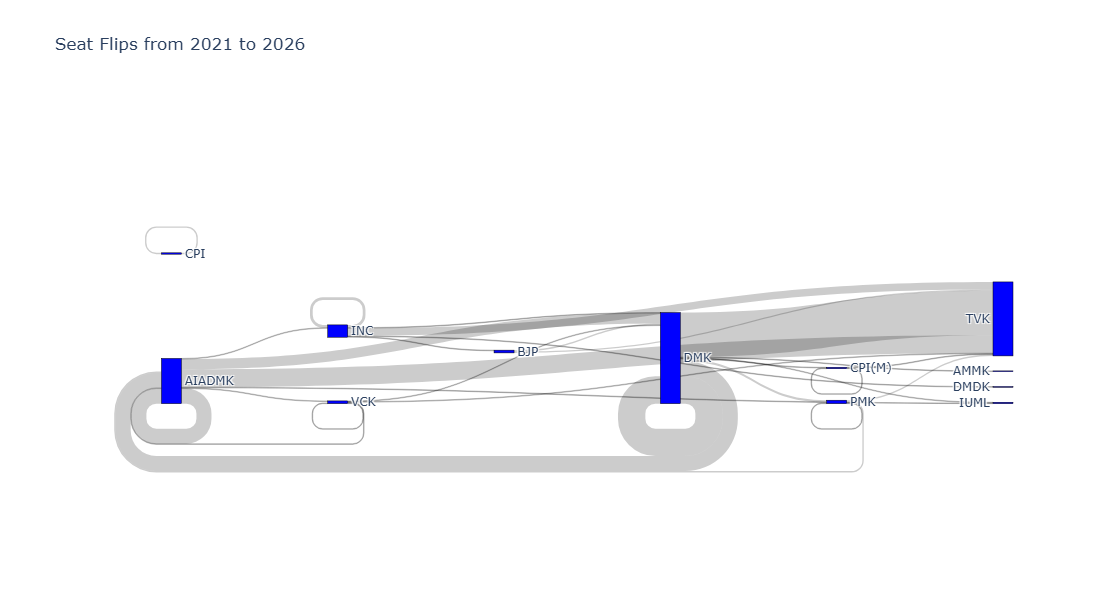

Flip matrix (counts):
winner_party_2026  AIADMK  AMMK  BJP  CPI  CPI(M)  DMDK  DMK  INC  IUML  PMK  \
winner_party_2021                                                              
AIADMK                 22     0    0    0       0     0   15    1     1    0   
BJP                     0     0    0    0       0     0    2    0     0    0   
CPI                     0     0    0    2       0     0    0    0     0    0   
CPI(M)                  0     0    0    0       1     0    0    0     0    0   
DMK                    22     1    0    0       1     0   40    0     1    3   
INC                     0     0    1    0       0     1    1    4     0    0   
PMK                     2     0    0    0       0     0    0    0     0    1   
VCK                     1     0    0    0       0     0    1    0     0    0   

winner_party_2026  TVK  VCK  
winner_party_2021            
AIADMK              26    1  
BJP                  2    0  
CPI                  0    0  
CPI(M)               1    0

In [12]:
# Install plotly if not present
!pip install plotly

import plotly.graph_objects as go
import pandas as pd

# Create flow data: from 2021 winner party to 2026 winner party
flow = merged.groupby(['winner_party_2021', 'winner_party_2026']).size().reset_index(name='count')

# Remove rows where count is zero
flow = flow[flow['count'] > 0]

# Prepare labels: unique parties from both years
labels = list(set(flow['winner_party_2021']).union(set(flow['winner_party_2026'])))
label_to_index = {label: i for i, label in enumerate(labels)}

# Build source, target, value
source = [label_to_index[p] for p in flow['winner_party_2021']]
target = [label_to_index[p] for p in flow['winner_party_2026']]
value = flow['count'].tolist()

# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color="blue"
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(title_text="Seat Flips from 2021 to 2026", font_size=12, width=800, height=600)
fig.show()

# Also print the flip matrix
print("Flip matrix (counts):")
flip_matrix = pd.crosstab(merged['winner_party_2021'], merged['winner_party_2026'])
print(flip_matrix)

In [13]:
#TVK's Vote Sources – Where did TVK's votes come from?

In [14]:
# Aggregate total votes per party per constituency in 2021 and 2026
def party_vote_share(df, year):
    # Group by ac_number and party, sum votes
    party_votes = df.groupby(['ac_number', 'party'])['votes'].sum().reset_index()
    # Get total valid votes per constituency
    total_votes = df.groupby('ac_number')['votes'].sum().reset_index(name='total_votes')
    # Merge
    party_votes = party_votes.merge(total_votes, on='ac_number')
    party_votes['vote_share'] = (party_votes['votes'] / party_votes['total_votes']) * 100
    party_votes['year'] = year
    return party_votes[['ac_number', 'party', 'vote_share', 'year']]

vote_share_2021 = party_vote_share(df_2021, 2021)
vote_share_2026 = party_vote_share(df_2026, 2026)

# Merge to see change
vote_share_change = vote_share_2021.merge(vote_share_2026, on=['ac_number', 'party'], suffixes=('_2021', '_2026'), how='outer')
vote_share_change['change'] = vote_share_change['vote_share_2026'] - vote_share_change['vote_share_2021']

# Focus on TVK's impact: For each constituency, which party lost the most vote share where TVK gained?
tvk_gains = vote_share_change[vote_share_change['party'] == 'TVK'][['ac_number', 'change']].rename(columns={'change': 'tvk_gain'})
# Get other parties' losses
other_losses = vote_share_change[vote_share_change['party'] != 'TVK']
# Merge to see correlation
loss_vs_gain = other_losses.merge(tvk_gains, on='ac_number', how='inner')
# For each constituency, find the party with largest loss
largest_loss = loss_vs_gain.loc[loss_vs_gain.groupby('ac_number')['change'].idxmin()]
# Summarize
print("TVK's vote sources: Which parties lost the most where TVK gained?")
summary = largest_loss.groupby('party').agg({'ac_number': 'count', 'change': 'mean'}).rename(columns={'ac_number': 'constituencies_count', 'change': 'avg_loss_percentage'})
print(summary.sort_values('constituencies_count', ascending=False))

TVK's vote sources: Which parties lost the most where TVK gained?
        constituencies_count  avg_loss_percentage
party                                            
DMK                      119           -16.904631
AIADMK                    77           -15.852988
INC                       14           -15.992425
NTK                        7            -4.718633
PMK                        7           -14.999861
BJP                        2           -16.973128
IND                        2           -15.568257
VCK                        2            -9.506972
CPI                        1           -24.155056
CPI(M)                     1           -16.345367
NOTA                       1            -0.097186


In [15]:
# Export winners tables
winners_2021.to_csv('winners_2021.csv', index=False)
winners_2026.to_csv('winners_2026.csv', index=False)

# Export merged data (with flips, margins, seat_type)
merged.to_csv('merged_analysis.csv', index=False)

# Export constituency master (already have, but ensure it's there)
master.to_csv('constituency_master.csv', index=False)  # if not already

# Export vote share change (for TVK analysis)
vote_share_change.to_csv('vote_share_change.csv', index=False)

print("All CSV files exported successfully.")

All CSV files exported successfully.
